In [ ]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [ ]:
#Loading and exploring the AAPL stock dataset

url = "https://raw.githubusercontent.com/kristoffer-paulsson/stock-data/master/aapl.csv"
data = pd.read_csv(url, sep=";")
data["date"] = pd.to_datetime(data["date"])
print("Dataset shape:", data.shape)
print("\nColumns:")

print(data.columns.tolist())
print("\nFirst 5 rows:")

print(data.head())
print("\nDataset information:")
print(data.info())


Dataset shape: (9400, 6)

Columns:
['date', 'open', 'high', 'low', 'close', 'volume']

First 5 rows:
        date   open   high    low  close     volume
0 1980-12-12  28.75  28.87  28.75  28.75  2093900.0
1 1980-12-15  27.38  27.38  27.25  27.25   785200.0
2 1980-12-16  25.37  25.37  25.25  25.25   472000.0
3 1980-12-17  25.87  26.00  25.87  25.87   385900.0
4 1980-12-18  26.63  26.75  26.63  26.63   327900.0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    9400 non-null   datetime64[ns]
 1   open    9400 non-null   float64       
 2   high    9400 non-null   float64       
 3   low     9400 non-null   float64       
 4   close   9400 non-null   float64       
 5   volume  9400 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 440.8 KB
None


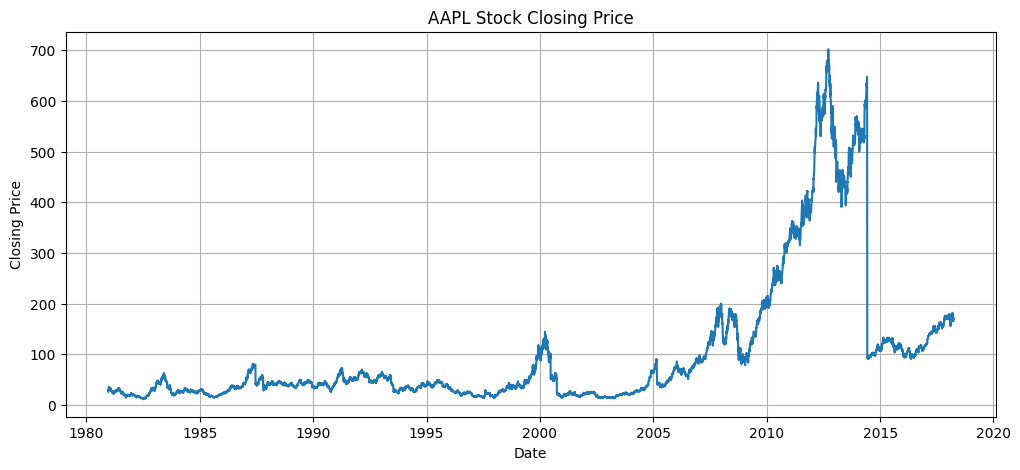

In [ ]:
# Visualizing the historical closing price

plt.figure(figsize=(12, 5))
plt.plot(
    data["date"],
    data["close"]
)

plt.title("AAPL Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid()
plt.show()

In [ ]:
# Preprocessing and normalizing the closing prices

prices = data[["close"]].dropna().values
print("Number of prices:", len(prices))

# Normalize values between 0 and 1

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)
print("Normalized data shape:", scaled_prices.shape)
print("\nFirst 5 normalized values:")
print(scaled_prices[:5])


Number of prices: 9400
Normalized data shape: (9400, 1)

First 5 normalized values:
[[0.02568369]
 [0.02351324]
 [0.0206193 ]
 [0.02151642]
 [0.02261612]]


In [ ]:
# Creating time-series sequences using the previous 60 days

X = []
y = []
sequence_length = 60
for i in range(sequence_length, len(scaled_prices)):
    # Previous 60 days
    X.append(scaled_prices[i-sequence_length:i, 0])
    # Current day's price
    y.append(scaled_prices[i, 0])
X = np.array(X)
y = np.array(y)

# Reshape X for LSTM

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9340, 60, 1)
y shape: (9340,)


In [ ]:
# Splitting the data into training and testing sets

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining X shape:", X_train.shape)
print("Testing X shape:", X_test.shape)

Training samples: 7472
Testing samples: 1868

Training X shape: (7472, 60, 1)
Testing X shape: (1868, 60, 1)


In [ ]:
# Creating the LSTM neural network

model = Sequential([
    LSTM(
        50,
        return_sequences=True,
        input_shape=(60, 1)
    ),
    Dropout(0.2),
    LSTM(
        50,
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(1)
])
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the LSTM model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nModel training completed successfully!")

Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 3.3925e-04 - val_loss: 0.0027
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 1.3608e-04 - val_loss: 0.0016
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 9.8726e-05 - val_loss: 0.0015
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 9.5278e-05 - val_loss: 0.0014
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 9.2798e-05 - val_loss: 0.0014
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 8.2422e-05 - val_loss: 0.0020
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 8.4714e-05 - val_loss: 0.0013
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 7.6483e-05 - val_loss: 0.0012
Epoch 9/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 7.0451e-05 - val_loss: 0.0013
Epoch 10/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 7.5888e-05 - val_loss: 0.0010
Epoch 11/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 6.7730e-05 - val_loss

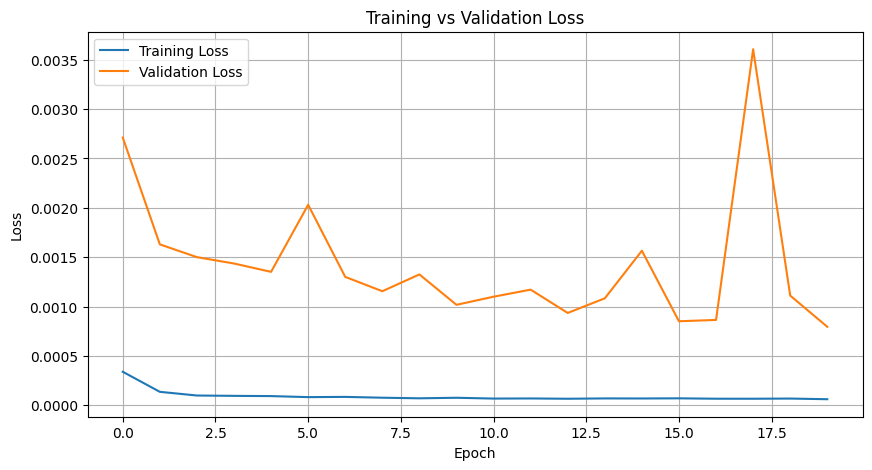

In [ ]:
# Plotting training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# Generating predictions on the test data

predictions = model.predict(X_test)

# Convert normalized predictions back to original price
predictions = scaler.inverse_transform(predictions)

# Convert actual normalized values back to original price
actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Predictions generated successfully!")

print("\nFirst 5 Actual Prices:")
print(actual[:5])

print("\nFirst 5 Predicted Prices:")
print(predictions[:5])



59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Predictions generated successfully!

First 5 Actual Prices:
[[309.52]
 [307.47]
 [308.84]
 [308.05]
 [307.83]]

First 5 Predicted Prices:
[[312.5017 ]
 [311.96497]
 [310.67615]
 [309.8185 ]
 [309.12604]]


In [ ]:
# Evaluating the LSTM model using MAE and RMSE

mae = mean_absolute_error(
    actual,
    predictions
)
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)
print("       MODEL EVALUATION")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

       MODEL EVALUATION
Mean Absolute Error (MAE): 6.950761945390394
Root Mean Squared Error (RMSE): 19.4841117009053


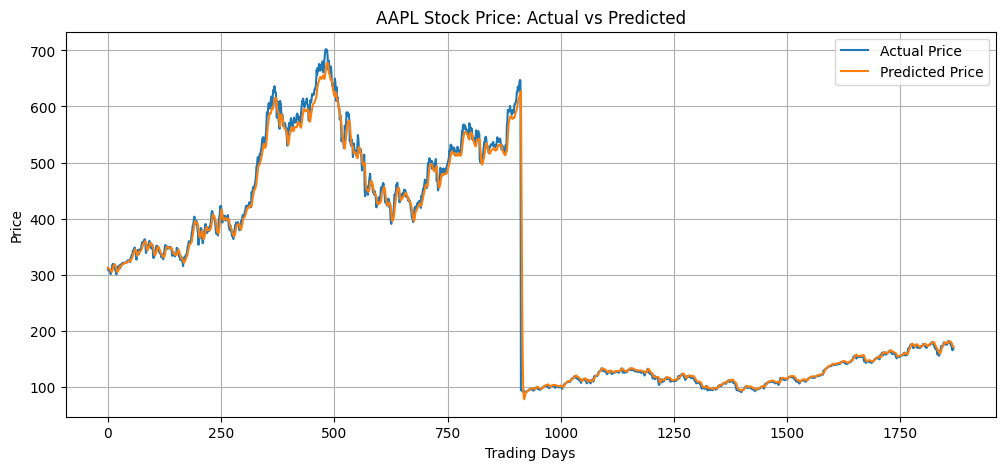

In [ ]:
# Plotting actual vs predicted stock prices

plt.figure(figsize=(12, 5))

plt.plot(
    actual,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.xlabel("Trading Days")
plt.ylabel("Price")

plt.title(
    "AAPL Stock Price: Actual vs Predicted"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
# 13] Predicting the next closing price

# Get the most recent 60 days
last_60_days = scaled_prices[-60:]

# Reshape for LSTM input
last_60_days = last_60_days.reshape(
    1,
    60,
    1
)
# Predict next day's normalized price
next_price = model.predict(last_60_days)

# Convert back to actual price
next_price = scaler.inverse_transform(
    next_price
)
predicted_price = float(next_price[0][0])
print("     NEXT DAY PRICE PREDICTION")
print(
    "Predicted next closing price: $",
    round(predicted_price, 2)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
     NEXT DAY PRICE PREDICTION
Predicted next closing price: $ 170.49
